# Smart Fund Advisor — Notebook 1: EDA & Feature Engineering

**Objective:** 
Explore the bank user dataset (50 k rows × 27 cols) and mutual fund catalogue (16 k rows × 16 cols).  
Engineer the **15 risk-appetite features** (including 3 new derived ratios: EMI-Income Ratio, Savings Rate, Credit History Score) and derive the 5-class risk label via composite scoring.

---
| Dataset | Rows | Unique Customers | Key Signal |
|---------|------|-----------------|------------|
| `bank_user_dataset.csv` | ~50 000 | ~12 500 | 8 months of financial behaviour per user |
| `mutual_fund_data.csv`  | ~16 228 | 16 228 | Fund NAV, AUM, category, AMC |

**New Features (v2):**
- `EMI_Income_Ratio` — Monthly EMI burden relative to income (higher = riskier)
- `Savings_Rate` — (Income − Expenses − EMI) / Income (higher = more conservative)
- `Credit_History_Score` — Normalised credit history length (longer = lower risk)

In [1]:
# ── 0. Bootstrap path so notebooks can import from src/ ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))
#os.chdir('..')   # make cwd the project root

# Purge any stale src module cache so changes to src/ are picked up fresh
for _mod in list(sys.modules.keys()):
    if _mod.startswith('src') or _mod == 'config':
        del sys.modules[_mod]

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Shared save directory (works regardless of cwd) ──
save_dir = os.path.join(os.path.abspath('..'), 'models')
os.makedirs(save_dir, exist_ok=True)

print('Libraries loaded ✓')
print(f'Plot save dir : {save_dir}')


Libraries loaded ✓
Plot save dir : /Users/chaitanya/Downloads/Submission/Code/20Feb26/models


In [2]:

# ── 1. Load raw bank dataset + Cleaning Audit ──
import pandas as pd, numpy as np, os
from src.preprocessing import load_and_clean, NON_NEGATIVE_COLS, COLUMN_BOUNDS

RAW_CSV = os.path.join(os.path.abspath('..'), 'Data', 'bank_user_dataset.csv')

# ── Step 0: read raw CSV to quantify issues BEFORE cleaning ──
_raw = pd.read_csv(RAW_CSV)
for c in _raw.columns:
    _raw[c] = pd.to_numeric(_raw[c].astype(str).str.replace(',', ''), errors='coerce')

print("=== BEFORE CLEANING: Range Violations ===")
print(f"{'Column':<28} {'Valid Range':>14}  {'Below Lo':>10}  {'Above Hi':>10}  {'Null':>8}")
print("-" * 75)
for col, (lo, hi) in COLUMN_BOUNDS.items():
    if col in _raw.columns:
        below = int((_raw[col] < lo).sum())
        above = int((_raw[col] > hi).sum())
        null  = int(_raw[col].isna().sum())
        print(f"  {col:<26} [{lo:>4} – {hi:>4}]  {below:>10}  {above:>10}  {null:>8}")

for col in NON_NEGATIVE_COLS:
    if col in _raw.columns:
        neg  = int((_raw[col] < 0).sum())
        null = int(_raw[col].isna().sum())
        print(f"  {col:<26} [   0 –  inf]  {neg:>10}  {'n/a':>10}  {null:>8}")

# ── Step 1: count how many nulls will be filled per-customer vs global-median ──
print("\n=== NULL-FILL SOURCE (per-customer ffill/bfill vs global-median fallback) ===")
print(f"{'Column':<28} {'Per-Cust Fill':>14}  {'GlobalMed Fill':>14}")
print("-" * 60)
_tmp = _raw.copy()
for col, (lo, hi) in COLUMN_BOUNDS.items():
    if col in _tmp.columns:
        _tmp[col] = _tmp[col].where(_tmp[col].between(lo, hi), other=np.nan)
for col in NON_NEGATIVE_COLS:
    if col in _tmp.columns:
        _tmp[col] = _tmp[col].clip(lower=0)

for col in _tmp.select_dtypes(include=[np.number]).columns:
    if 'Customer_ID' not in _tmp.columns:
        break
    before_null = int(_tmp[col].isna().sum())
    if before_null == 0:
        continue
    after_pc = _tmp.groupby('Customer_ID')[col].transform(lambda x: x.ffill().bfill())
    per_cust = int(before_null - after_pc.isna().sum())
    global_f = int(after_pc.isna().sum())
    if per_cust + global_f > 0:
        print(f"  {col:<26} {per_cust:>14}  {global_f:>14}")

# ── Step 2: run full clean and validate ──
df_raw = load_and_clean()
print(f"\n=== AFTER CLEANING ===")
print(f"Shape: {df_raw.shape}  |  Unique customers: {df_raw['Customer_ID'].nunique()}")
print(f"Total nulls remaining (num cols): {df_raw.select_dtypes(include=[np.number]).isnull().sum().sum()}")
print(f"\nRange-bounded column stats (min / max):")
for col, (lo, hi) in COLUMN_BOUNDS.items():
    if col in df_raw.columns:
        print(f"  {col:<28}  min={df_raw[col].min():.1f}  max={df_raw[col].max():.1f}  "
              f"[valid: {lo}–{hi}]  violations={'NONE ✓' if (df_raw[col]<lo).sum()+(df_raw[col]>hi).sum()==0 else 'FAIL ✗'}")


=== BEFORE CLEANING: Range Violations ===
Column                          Valid Range    Below Lo    Above Hi      Null
---------------------------------------------------------------------------
  Age                        [  10 –  100]         464         895      2477
  Num_Bank_Accounts          [   0 –   20]          16         635         0
  Num_of_Loan                [   0 –   50]        1974         246      2436
  Interest_Rate              [   0 –   50]           0         966         0
  Num_Credit_Card            [   0 –   50]           0        1150         0
  Num_of_Delayed_Payment     [   0 –  100]         275         377      4925
  Delay_from_due_date        [   0 –  inf]         298         n/a         0

=== NULL-FILL SOURCE (per-customer ffill/bfill vs global-median fallback) ===
Column                        Per-Cust Fill  GlobalMed Fill
------------------------------------------------------------
  ID                                  50000               0
  Cus


=== AFTER CLEANING ===
Shape: (50000, 31)  |  Unique customers: 12500
Total nulls remaining (num cols): 0

Range-bounded column stats (min / max):
  Age                           min=14.0  max=95.0  [valid: 10–100]  violations=NONE ✓
  Num_Bank_Accounts             min=0.0  max=11.0  [valid: 0–20]  violations=NONE ✓
  Num_of_Loan                   min=0.0  max=50.0  [valid: 0–50]  violations=NONE ✓
  Interest_Rate                 min=1.0  max=34.0  [valid: 0–50]  violations=NONE ✓
  Num_Credit_Card               min=0.0  max=50.0  [valid: 0–50]  violations=NONE ✓
  Num_of_Delayed_Payment        min=0.0  max=100.0  [valid: 0–100]  violations=NONE ✓


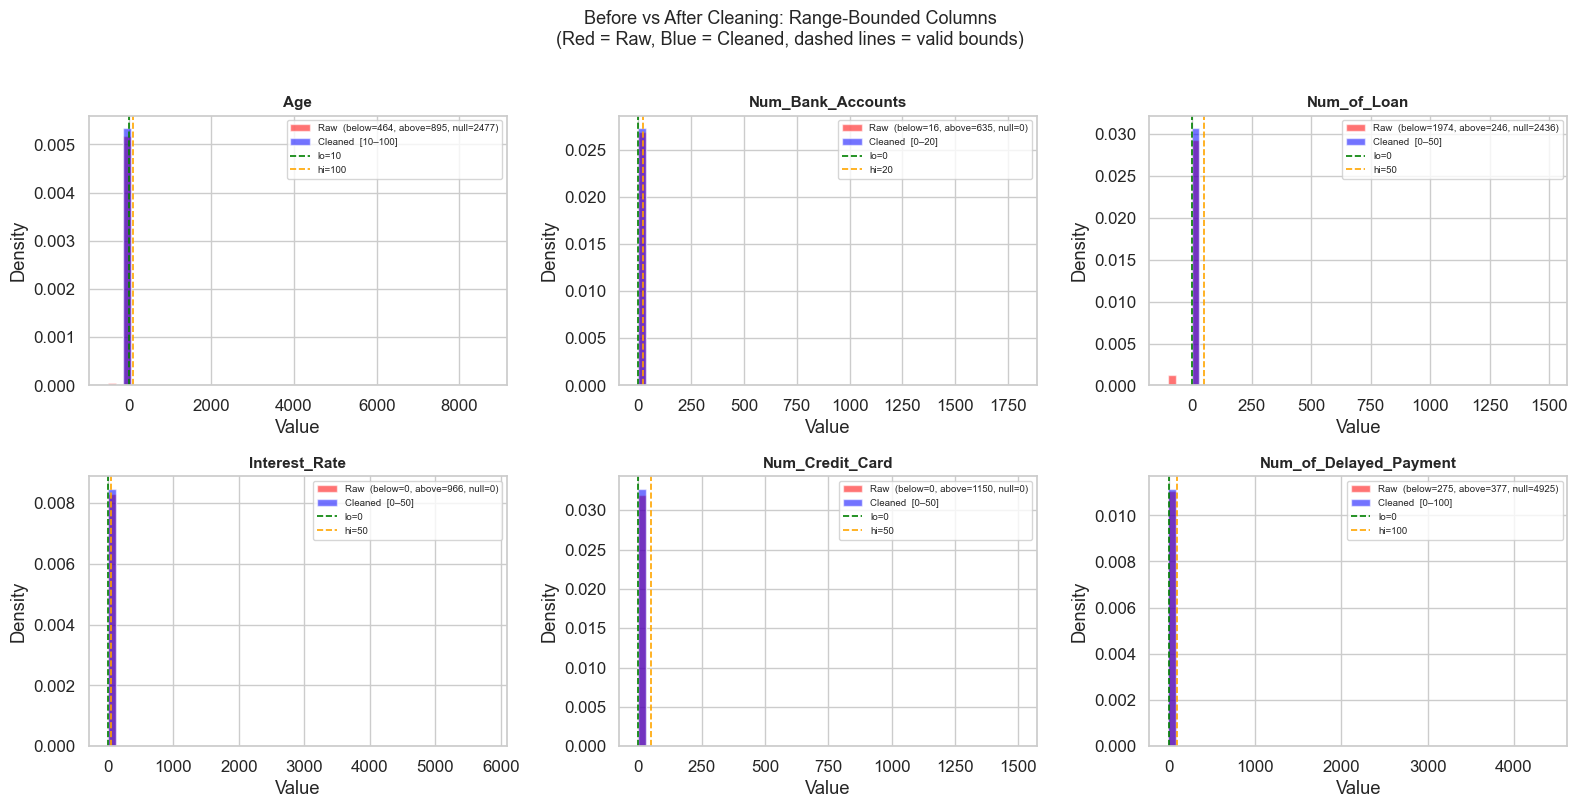

Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_cleaning_before_after.png


In [3]:

# ── 1b. Before/After Cleaning: Histogram comparison for Range-Bounded Columns ──
import matplotlib.pyplot as plt, numpy as np, os, pandas as pd
from src.preprocessing import COLUMN_BOUNDS

RAW_CSV = os.path.join(os.path.abspath('..'), 'Data', 'bank_user_dataset.csv')

_raw2 = pd.read_csv(RAW_CSV)
for c in _raw2.columns:
    _raw2[c] = pd.to_numeric(_raw2[c].astype(str).str.replace(',', ''), errors='coerce')

avail_cols = [c for c in COLUMN_BOUNDS if c in _raw2.columns and c in df_raw.columns]
ncols = 3
nrows = int(np.ceil(len(avail_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(avail_cols):
    ax = axes[i]
    lo, hi = COLUMN_BOUNDS[col]
    raw_vals   = _raw2[col].dropna()
    clean_vals = df_raw[col].dropna()

    below = int((raw_vals < lo).sum())
    above = int((raw_vals > hi).sum())
    null  = int(_raw2[col].isna().sum())

    combined_min = min(raw_vals.min(), clean_vals.min())
    combined_max = max(raw_vals.max(), clean_vals.max())
    bins = np.linspace(combined_min, combined_max, 50)

    ax.hist(raw_vals,   bins=bins, alpha=0.55, color='red',  label=f'Raw  (below={below}, above={above}, null={null})', density=True)
    ax.hist(clean_vals, bins=bins, alpha=0.55, color='blue', label=f'Cleaned  [{lo}–{hi}]', density=True)
    ax.axvline(lo, color='green',  ls='--', lw=1.2, label=f'lo={lo}')
    ax.axvline(hi, color='orange', ls='--', lw=1.2, label=f'hi={hi}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for j in range(len(avail_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Before vs After Cleaning: Range-Bounded Columns\n(Red = Raw, Blue = Cleaned, dashed lines = valid bounds)', fontsize=13, y=1.01)
plt.tight_layout()
out_path = os.path.join(save_dir, 'plot_cleaning_before_after.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")


count    12500.0
mean         4.0
std          0.0
min          4.0
25%          4.0
50%          4.0
75%          4.0
max          4.0
dtype: float64


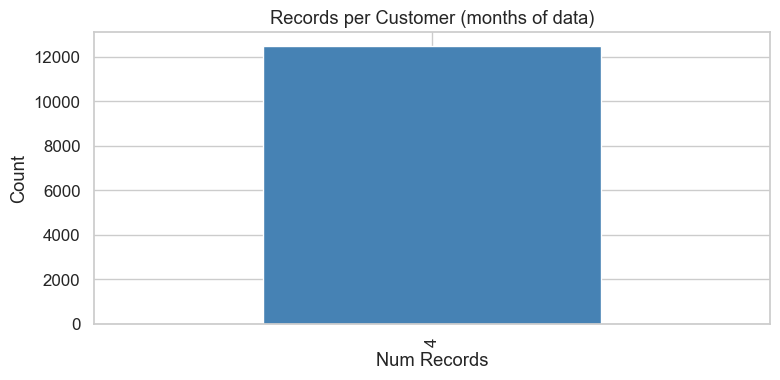

In [4]:
# ── 2. Records per customer distribution ──
rpc = df_raw.groupby('Customer_ID').size()
print(rpc.describe())

fig, ax = plt.subplots(figsize=(8, 4))
rpc.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Records per Customer (months of data)')
ax.set_xlabel('Num Records'); ax.set_ylabel('Count')
plt.tight_layout()
# os.makedirs('models', exist_ok=True)
plt.savefig(os.path.join(save_dir, 'plot_records_per_customer.png'), dpi=150)
plt.show()

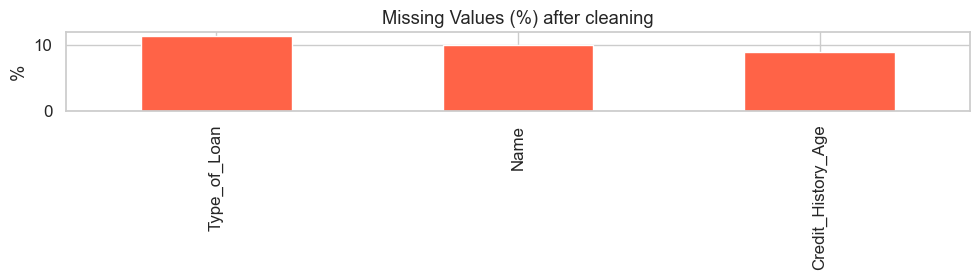

In [5]:
# ── 3. Missing value heatmap ──
missing_pct = df_raw.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
if not missing_pct.empty:
    fig, ax = plt.subplots(figsize=(10, 3))
    missing_pct.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Values (%) after cleaning')
    ax.set_ylabel('%')
    plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_missing_values.png'), dpi=150)
    plt.show()
else:
    print('No missing values after cleaning ✓')

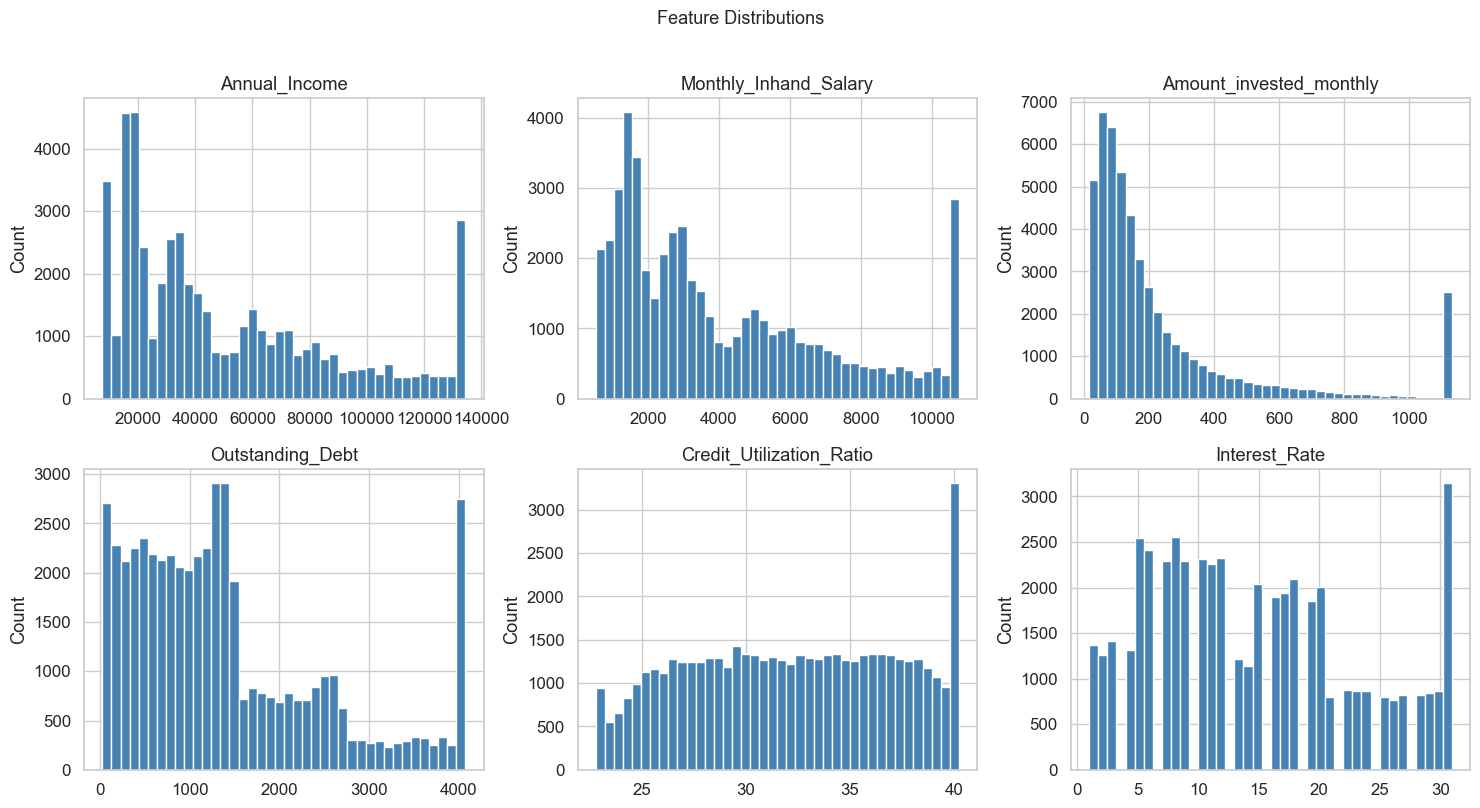

                Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  50000.000000   50000.000000           50000.000000       50000.000000   
mean      33.816760   52514.969419            4175.207722           5.370840   
std       10.770953   43048.787869            3152.139795           2.593355   
min       14.000000    7534.185000             530.050833           0.000000   
25%       25.000000   19453.327500            1623.593333           3.000000   
50%       33.000000   37577.820000            3081.902500           5.000000   
75%       42.000000   72817.020000            5936.446667           7.000000   
max       95.000000  251613.340000           13780.774640          11.000000   

       Num_Credit_Card  Interest_Rate   Num_of_Loan  Delay_from_due_date  \
count     50000.000000   50000.000000  50000.000000         50000.000000   
mean          5.551780      14.532080      3.535560            21.066760   
std           2.216018       8.741374      2.466904

In [6]:
# ── 4. Key feature distributions ──
num_cols = ['Annual_Income', 'Monthly_Inhand_Salary',
            'Amount_invested_monthly', 'Outstanding_Debt',
            'Credit_Utilization_Ratio', 'Interest_Rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    if col in df_raw.columns:
        df_raw[col].dropna().clip(
            df_raw[col].quantile(0.01), df_raw[col].quantile(0.95)
        ).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col); ax.set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(df_raw.describe())

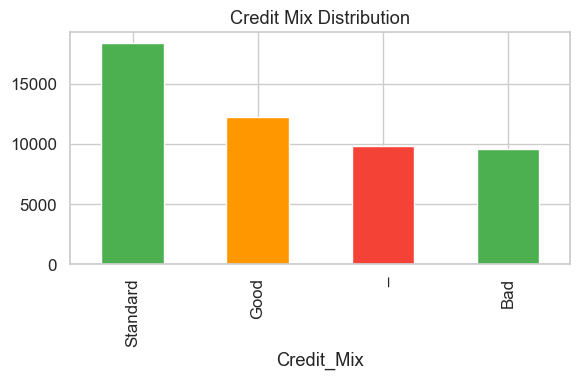

In [7]:
# ── 5. Credit Mix distribution ──
fig, ax = plt.subplots(figsize=(6, 4))
if 'Credit_Mix' in df_raw.columns:
    df_raw['Credit_Mix'].str.strip().value_counts().plot(
        kind='bar', ax=ax, color=['#4CAF50','#FF9800','#F44336'], edgecolor='white'
    )
ax.set_title('Credit Mix Distribution')
plt.tight_layout(); plt.show()

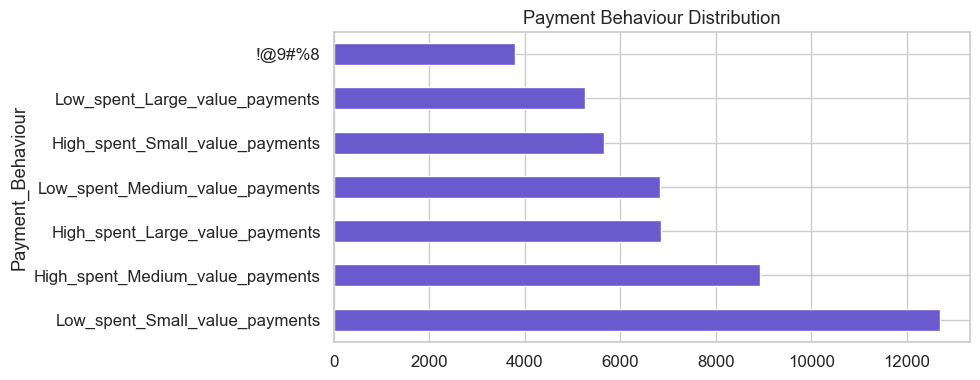

In [8]:
# ── 6. Payment Behaviour distribution ──
fig, ax = plt.subplots(figsize=(10, 4))
if 'Payment_Behaviour' in df_raw.columns:
    df_raw['Payment_Behaviour'].str.strip().value_counts().plot(
        kind='barh', ax=ax, color='slateblue', edgecolor='white'
    )
ax.set_title('Payment Behaviour Distribution')
plt.tight_layout(); plt.show()

In [9]:
# ── 7. Per-customer feature engineering + risk labelling ──
from src.preprocessing import aggregate_per_customer, engineer_features
from src.risk_labeling  import assign_risk_label, FEATURE_WEIGHTS

df_agg  = aggregate_per_customer(df_raw)
df_feat = engineer_features(df_agg, fit_scaler=True)
df_lab  = assign_risk_label(df_feat, fit_encoder=True)

print(f'Per-customer records: {len(df_lab)}')
print(df_lab['risk_label'].value_counts())

Per-customer records: 12500
risk_label
Low          3125
High         3125
Medium       3124
Very_High    1563
Very_Low     1563
Name: count, dtype: int64


=== New Derived Features (v2) ===
  EMI_Income_Ratio           min=0.0000  mean=0.1000  max=1.0000
  Savings_Rate               min=0.0000  mean=0.8839  max=1.0000
  Credit_History_Score       min=0.0000  mean=0.5457  max=1.0000


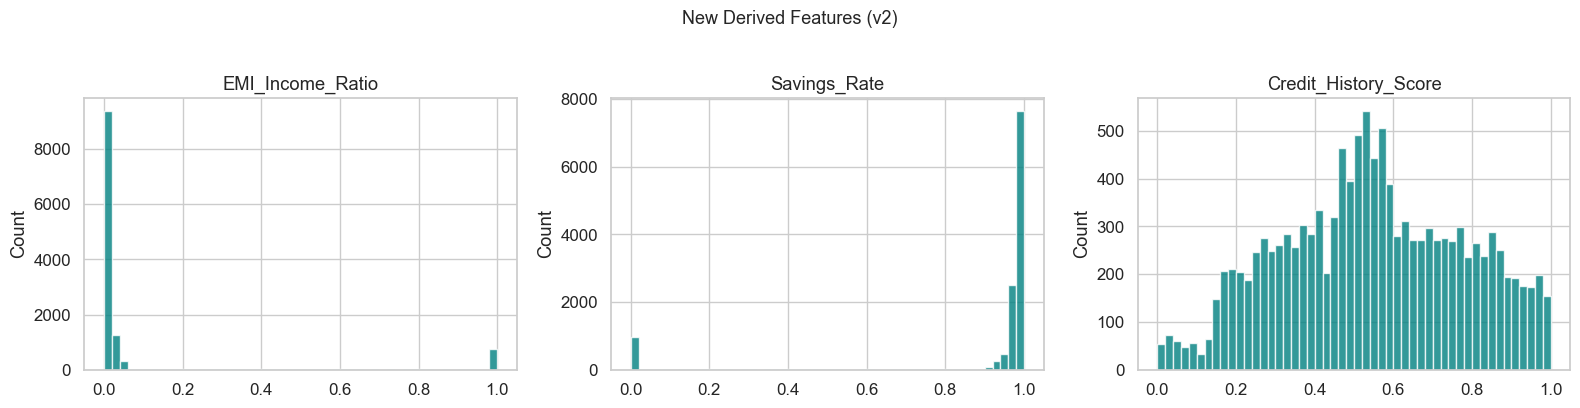


All 3 new features present and non-null


In [10]:
# ── 7a. Inspect the 3 new features (v2) ──
new_feats = ['EMI_Income_Ratio', 'Savings_Rate', 'Credit_History_Score']
print("=== New Derived Features (v2) ===")
for feat in new_feats:
    if feat in df_lab.columns:
        vals = df_lab[feat]
        print(f"  {feat:25s}  min={vals.min():.4f}  mean={vals.mean():.4f}  max={vals.max():.4f}")
    else:
        print(f"  {feat:25s}  NOT FOUND in df_lab")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, new_feats):
    if feat in df_lab.columns:
        df_lab[feat].hist(bins=50, ax=ax, color='teal', edgecolor='white', alpha=0.8)
        ax.set_title(feat)
        ax.set_ylabel('Count')
plt.suptitle('New Derived Features (v2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'plot_new_features_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAll {len(new_feats)} new features present and non-null")

---
## Raw Risk Score Distribution — Before Bell-Curve Binning

The composite score `Σ(weight × feature)` is a continuous number.  
**Bell-curve `pd.qcut` bins** are applied using `RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]`, giving:

| Class | Quantile Range | Target % |
|-------|---------------|----------|
| Very_Low | 0% – 12.5% | **12.5%** |
| Low | 12.5% – 37.5% | **25.0%** |
| Medium | 37.5% – 62.5% | **25.0%** |
| High | 62.5% – 87.5% | **25.0%** |
| Very_High | 87.5% – 100% | **12.5%** |

The plots below show the raw score shape and the final label distribution after binning.


Raw risk score range: -4.5372 to 10.2774
=== Raw Risk Score Statistics (before bell-curve qcut) ===
count    12500.0000
mean         4.4998
std          2.1164
min         -4.5372
25%          3.2018
50%          4.6469
75%          5.9795
max         10.2774

Bell-curve qcut boundaries (RISK_QUANTILES=[0.0, 0.125, 0.375, 0.625, 0.875, 1.0]): [-4.537, 2.014, 3.986, 5.286, 6.865, 10.277]

Customers per bin after bell-curve qcut:
  Very_Low    :  1563  (12.5%)
  Low         :  3125  (25.0%)
  Medium      :  3124  (25.0%)
  High        :  3125  (25.0%)
  Very_High   :  1563  (12.5%)

Actual label counts in df_lab (from assign_risk_label, should match above):
  Very_Low    :  1563  (12.5%) ✓
  Low         :  3125  (25.0%) ✓
  Medium      :  3124  (25.0%) ✓
  High        :  3125  (25.0%) ✓
  Very_High   :  1563  (12.5%) ✓


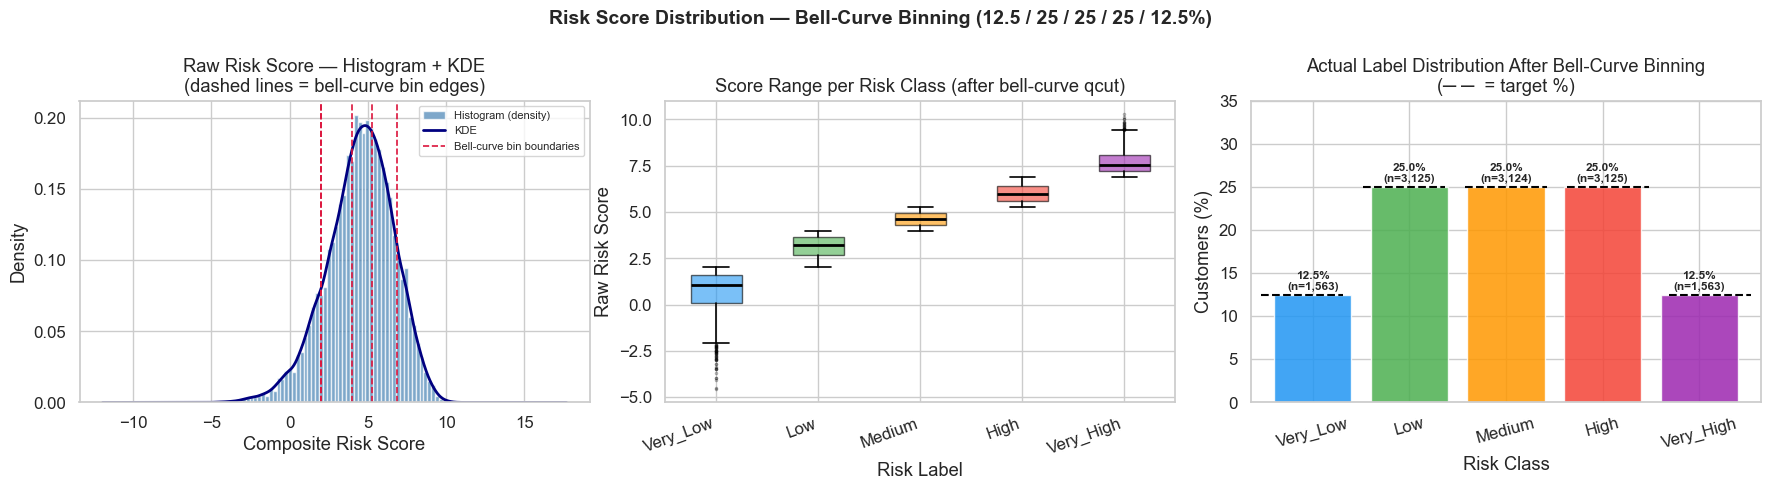


✓ Bell-curve binning confirmed: Very_Low≈12.5%, Low≈25%, Medium≈25%, High≈25%, Very_High≈12.5%
  RISK_QUANTILES used: [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]


In [11]:
# ── 7b. Raw risk score distribution — before bell-curve qcut ──────────────────
from src.risk_labeling import compute_risk_score, FEATURE_WEIGHTS, RISK_QUANTILES
from config import RISK_CLASSES

# Compute raw scores on the per-customer feature-engineered data
raw_scores = compute_risk_score(df_feat)

print(f"Raw risk score range: {raw_scores.min():.4f} to {raw_scores.max():.4f}")

# Compute the BELL-CURVE boundaries (RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0])
quintile_edges = pd.qcut(raw_scores, q=RISK_QUANTILES, retbins=True)[1]

print("=== Raw Risk Score Statistics (before bell-curve qcut) ===")
print(raw_scores.describe().round(4).to_string())
print(f"\nBell-curve qcut boundaries (RISK_QUANTILES={RISK_QUANTILES}): {[round(b, 3) for b in quintile_edges]}")
print(f"\nCustomers per bin after bell-curve qcut:")
binned = pd.qcut(raw_scores, q=RISK_QUANTILES, labels=RISK_CLASSES)
counts_binned = binned.value_counts().reindex(RISK_CLASSES)
total = len(raw_scores)
for cls, cnt in counts_binned.items():
    pct = 100 * cnt / total
    print(f"  {cls:<12}: {cnt:5d}  ({pct:.1f}%)")

# Also check df_lab (actual labels from assign_risk_label)
print(f"\nActual label counts in df_lab (from assign_risk_label, should match above):")
actual_counts = df_lab['risk_label'].value_counts().reindex(RISK_CLASSES)
for cls, cnt in actual_counts.items():
    pct = 100 * cnt / len(df_lab)
    print(f"  {cls:<12}: {cnt:5d}  ({pct:.1f}%) {'✓' if abs(pct - ([12.5,25,25,25,12.5][RISK_CLASSES.index(cls)])) < 1 else '✗'}")

PALETTE = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
           'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Risk Score Distribution — Bell-Curve Binning (12.5 / 25 / 25 / 25 / 12.5%)",
             fontsize=14, fontweight='bold')

# ── Plot 1: Raw histogram + KDE with bell-curve boundaries ────────────────────
ax = axes[0]
ax.hist(raw_scores, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        density=True, label='Histogram (density)')
raw_scores.plot(kind='kde', ax=ax, color='navy', linewidth=2, label='KDE')
for edge in quintile_edges[1:-1]:
    ax.axvline(edge, color='crimson', linestyle='--', linewidth=1.2)
ax.axvline(quintile_edges[1], color='crimson', linestyle='--', linewidth=1.2,
           label='Bell-curve bin boundaries')
ax.set_title("Raw Risk Score — Histogram + KDE\n(dashed lines = bell-curve bin edges)")
ax.set_xlabel("Composite Risk Score")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ── Plot 2: Boxplot of per-class score ranges ─────────────────────────────────
ax = axes[1]
score_df = pd.DataFrame({'risk_score': raw_scores.values,
                          'risk_label': df_lab['risk_label'].values})
for i, label in enumerate(RISK_CLASSES):
    subset = score_df[score_df['risk_label'] == label]['risk_score']
    ax.boxplot(subset, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=PALETTE[label], alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2),
               flierprops=dict(marker='.', alpha=0.3, markersize=3))
ax.set_xticks(range(len(RISK_CLASSES)))
ax.set_xticklabels(RISK_CLASSES, rotation=20, ha='right')
ax.set_title("Score Range per Risk Class (after bell-curve qcut)")
ax.set_xlabel("Risk Label")
ax.set_ylabel("Raw Risk Score")

# ── Plot 3: Actual label distribution bar chart (bell-curve result) ───────────
ax = axes[2]
TARGET_PCT = {'Very_Low': 12.5, 'Low': 25.0, 'Medium': 25.0, 'High': 25.0, 'Very_High': 12.5}
bars = ax.bar(RISK_CLASSES,
              [100 * actual_counts[c] / len(df_lab) for c in RISK_CLASSES],
              color=[PALETTE[c] for c in RISK_CLASSES],
              edgecolor='white', alpha=0.85)
# Target line overlay
for i, cls in enumerate(RISK_CLASSES):
    ax.axhline(TARGET_PCT[cls], xmin=(i + 0.1) / len(RISK_CLASSES),
               xmax=(i + 0.9) / len(RISK_CLASSES),
               color='black', linestyle='--', linewidth=1.5)
# Value labels on bars
for bar, cls in zip(bars, RISK_CLASSES):
    pct = 100 * actual_counts[cls] / len(df_lab)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n(n={actual_counts[cls]:,})',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title("Actual Label Distribution After Bell-Curve Binning\n(─ ─  = target %)")
ax.set_xlabel("Risk Class")
ax.set_ylabel("Customers (%)")
ax.set_ylim(0, 35)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()

# Save
import os
save_dir = os.path.join(os.path.abspath('..'), 'models')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'plot_raw_risk_score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Bell-curve binning confirmed: Very_Low≈12.5%, Low≈25%, Medium≈25%, High≈25%, Very_High≈12.5%")
print(f"  RISK_QUANTILES used: {RISK_QUANTILES}")


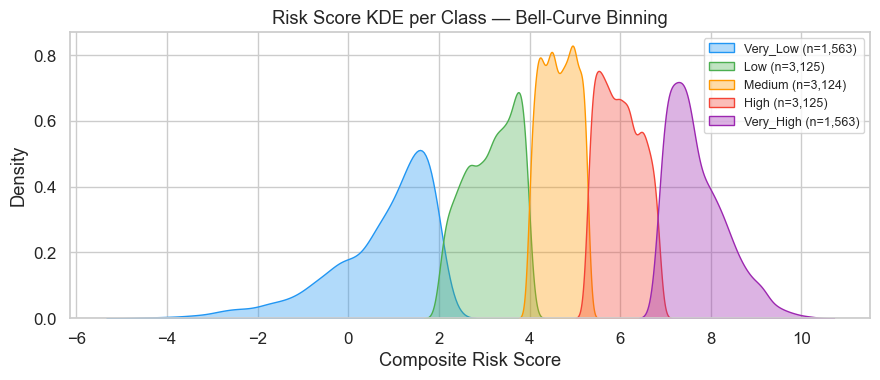

In [12]:
# ── KDE overlay: raw score for each risk class (bell-curve shape confirmed) ───
fig, ax = plt.subplots(figsize=(9, 4))
for cls in RISK_CLASSES:
    subset_scores = score_df[score_df['risk_label'] == cls]['risk_score']
    sns.kdeplot(subset_scores, fill=True, alpha=0.35, color=PALETTE[cls],
                label=f"{cls} (n={len(subset_scores):,})", ax=ax)
ax.set_title("Risk Score KDE per Class — Bell-Curve Binning")
ax.set_xlabel("Composite Risk Score")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'plot_raw_risk_score_distribution1.png'), dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# ── 8. Risk label distribution ──
from src.utils import plot_risk_distribution

plot_risk_distribution(
    df_lab['risk_label'].values,
    title='Risk Appetite Distribution — All Customers (5 Classes)',
    save_path=os.path.join(save_dir, 'plot_risk_distribution.png')
)

Saved distribution plot → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_risk_distribution.png


In [14]:
# ── 9. Feature importance (domain weights) ──
from src.utils import plot_feature_importance

plot_feature_importance(
    FEATURE_WEIGHTS,
    save_path=os.path.join(save_dir, 'plot_feature_importance.png')
)

Saved feature importance plot → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_feature_importance.png


In [15]:
# ── 10. Correlation heatmap of engineered features ──
from config import RISK_FEATURES

feat_available = [f for f in RISK_FEATURES if f in df_lab.columns]
corr = df_lab[feat_available].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_feature_correlation.png'), dpi=150)
plt.show()

In [16]:
# ── 11. Mutual Fund EDA ──
from src.recommender import load_mutual_funds

mf_df = load_mutual_funds()
print(f'Mutual Fund catalogue: {len(mf_df)} funds, {mf_df["AMC"].nunique()} AMCs')

print('\nRisk Tier Assignment:')
print(mf_df['risk_tier'].value_counts(dropna=False))

Mutual Fund catalogue: 14270 funds, 51 AMCs

Risk Tier Assignment:
risk_tier
Low          6393
Medium       3162
High         3028
Very_Low      863
Very_High     824
Name: count, dtype: int64


In [17]:
# ── 12. Mutual fund risk tier distribution (ordered Very_Low → Very_High) ──
from config import RISK_CLASSES as RC_MF
PALETTE_TIER = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
                'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}
mf_tier = mf_df['risk_tier'].dropna().value_counts().reindex(RC_MF, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4))
mf_tier.plot(kind='bar', ax=ax,
             color=[PALETTE_TIER[t] for t in RC_MF],
             edgecolor='white')
ax.set_title('Mutual Fund Count by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('Number of Funds')
for bar, cnt_val in zip(ax.patches, mf_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{cnt_val:,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_mf_risk_tiers.png'), dpi=150)
plt.show()


In [18]:
# ── 13. AUM distribution by risk tier (ordered Very_Low → Very_High) ──
fig, ax = plt.subplots(figsize=(10, 5))
mf_df_plot = mf_df.dropna(subset=['risk_tier', 'Average_AUM_Cr']).copy()
mf_df_plot['Average_AUM_Cr_log'] = np.log1p(
    pd.to_numeric(mf_df_plot['Average_AUM_Cr'], errors='coerce').fillna(0))
RC_ordered = [r for r in RC_MF if r in mf_df_plot['risk_tier'].unique()]
sns.boxplot(data=mf_df_plot, x='risk_tier', y='Average_AUM_Cr_log',
            order=RC_ordered, ax=ax,
            palette={r: PALETTE_TIER[r] for r in RC_ordered},
            linewidth=0.8, fliersize=2)
ax.set_title('log(1+AUM) by Risk Tier — ordered Very_Low → Very_High\n'
             '(Liquid/overnight funds attract highest institutional AUM)')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('log1p(AUM in Cr)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_aum_by_tier.png'), dpi=150)
plt.show()


In [19]:
# ── 14. Investment ratio vs risk label ──
fig, ax = plt.subplots(figsize=(9, 4))
for label in df_lab['risk_label'].unique():
    ax.hist(
        df_lab[df_lab['risk_label'] == label]['Investment_Ratio'].clip(0, 2),
        bins=30, alpha=0.5, label=label, density=True
    )
ax.set_title('Investment Ratio Distribution by Risk Label')
ax.set_xlabel('Investment Ratio (capped at 2)')
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_inv_ratio_by_risk.png'), dpi=150)
plt.show()

In [20]:
# ── 15. NAV History — quick stats and reference date ──
from src.nav_history import nav_history_quick_stats, load_nav_metrics, _ref_date
from config import NAV_HISTORY_PARQUET

import os
if not NAV_HISTORY_PARQUET.exists():
    print(f"Parquet not found at: {NAV_HISTORY_PARQUET}")
else:
    stats = nav_history_quick_stats()
    ref   = _ref_date()

    print("─── NAV History Parquet — Quick Stats ───")
    print(f"  File            : {NAV_HISTORY_PARQUET.name}")
    print(f"  Total rows      : {stats['total_rows']:>12,}")
    print(f"  Schemes (sample): {stats['sample_schemes']:>12,}")
    print(f"  Date range      : {stats['sample_date_min'].date()} → {stats['sample_date_max'].date()}")
    print(f"  Reference date  : {ref.date()}  ← latest NAV date in parquet")
    print(f"  Row groups      : {stats['num_row_groups']}")
    print()

    nav_metrics = load_nav_metrics(verbose=True)
    print()
    print("─── NAV Metrics Cache — Summary ─────────")
    print(nav_metrics[['cagr_1yr','cagr_3yr','cagr_5yr',
                        'sharpe_1yr','max_drawdown','record_count']].describe().round(4))


─── NAV History Parquet — Quick Stats ───
  File            : mutual_fund_nav_history.parquet
  Total rows      :   21,357,943
  Schemes (sample):          222
  Date range      : 2006-04-01 → 2026-02-15
  Reference date  : 2026-02-15  ← latest NAV date in parquet
  Row groups      : 21

[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.

─── NAV Metrics Cache — Summary ─────────
         cagr_1yr    cagr_3yr    cagr_5yr  sharpe_1yr  max_drawdown  \
count  13616.0000  12062.0000  10263.0000   7889.0000     9082.0000   
mean       0.0606      0.0543      0.0389     -0.6208       -0.0996   
std        0.1413      0.0830      0.0746      2.7133        0.1056   
min       -0.8254     -0.5181     -0.6019    -10.0000       -0.9297   
25%        0.0000      0.0000      0.0000     -0.7669       -0.1844   
50%        0.0010      0.0004      0.0026      0.2480       -0.0617   


---
## Mutual Fund Dataset — Data Preparation & EDA

The sections below document preparation steps applied to the **mutual fund catalogue** (`Data/mutual_fund_data.csv`, 16 346 rows).
These steps run inside `src/recommender.load_mutual_funds()` and `src/ensemble_recommender.build_fund_features()` but were not previously shown here.

Key steps covered:
1. **Missing value analysis** — which columns have null rates and how they are handled.
2. **Univariate distributions** — NAV, AUM, Scheme_Type breakdown, active vs. inactive counts.
3. **Synthetic expense ratio** — the TER proxy constructed from fund traits (no TER in raw CSV).
4. **Fund feature engineering** — log transforms, boolean flags, and AMC frequency encoding.


In [21]:

# ── MF-1. Load fund catalogue and report missing values ───────────────────────
import pandas as pd
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.recommender import load_mutual_funds
from config import RISK_CLASSES

raw_mf = pd.read_csv('../Data/mutual_fund_data.csv', low_memory=False)
raw_mf.columns = [c.strip() for c in raw_mf.columns]

print(f"Raw mutual fund catalogue: {len(raw_mf):,} rows × {raw_mf.shape[1]} columns")
print(f"Unique AMCs       : {raw_mf['AMC'].nunique()}")
print(f"Unique categories : {raw_mf['Scheme_Category'].nunique()}")
print()

# Missing value summary
missing = raw_mf.isnull().sum()
missing_pct = 100 * missing / len(raw_mf)
mf_missing_df = pd.DataFrame({
    'Missing_Count': missing[missing > 0],
    'Missing_%':     missing_pct[missing > 0].round(2)
}).sort_values('Missing_%', ascending=False)

print("=== Missing Value Summary — Mutual Fund Catalogue ===")
print(mf_missing_df.to_string())
print()

# Treatment summary
print("=== Imputation / Drop Treatment ===")
print("  NAV                 → rows with null NAV are DROPPED (not imputable)")
print("  Average_AUM_Cr      → filled with 0 before log1p transform")
print("  Scheme_Min_Amt      → filled with 500 (SEBI minimum default) before log1p")
print("  Launch_Date         → NaT → fund_age_years = 0")
print("  Closure_Date        → NaT → is_active = 1 (open-ended)")
print("  Latest_NAV_Date     → NaT → nav_recency_days = 365 (proxy for dormant fund)")

# Show how many rows get dropped for null NAV
null_nav_count = raw_mf['NAV'].isna().sum() + (pd.to_numeric(raw_mf['NAV'], errors='coerce').isna().sum())
nav_numeric    = pd.to_numeric(raw_mf['NAV'], errors='coerce')
actually_null  = nav_numeric.isna().sum()
print(f"\n  Rows dropped for null/non-numeric NAV: {actually_null:,} "
      f"({100*actually_null/len(raw_mf):.2f}%)")
print(f"  Rows retained after NAV filter:        {len(raw_mf) - actually_null:,}")


Raw mutual fund catalogue: 16,346 rows × 16 columns
Unique AMCs       : 53
Unique categories : 50

=== Missing Value Summary — Mutual Fund Catalogue ===
                                         Missing_Count  Missing_%
Closure_Date                                     12489      76.40
Average_AUM_Cr                                    8306      50.81
AAUM_Quarter                                      8306      50.81
NAV                                               2076      12.70
Latest_NAV_Date                                   2076      12.70
ISIN_Div_Payout/Growth                            2076      12.70
ISIN_Div_Reinvestment                             2076      12.70
ISIN_Div_Payout/Growth/Div_Reinvestment           1410       8.63
Scheme_Min_Amt                                      30       0.18
Launch_Date                                         21       0.13

=== Imputation / Drop Treatment ===
  NAV                 → rows with null NAV are DROPPED (not imputable)
  Average_AUM

In [22]:

# ── MF-2. Univariate analysis: NAV, AUM, Scheme_Type, active/inactive ─────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mf_clean = raw_mf.copy()
mf_clean['NAV']             = pd.to_numeric(mf_clean['NAV'], errors='coerce')
mf_clean['Average_AUM_Cr']  = pd.to_numeric(mf_clean['Average_AUM_Cr'], errors='coerce')
mf_clean['Scheme_Min_Amt']  = pd.to_numeric(mf_clean['Scheme_Min_Amt'], errors='coerce')
mf_clean['Closure_Date']    = pd.to_datetime(mf_clean['Closure_Date'], errors='coerce')
mf_clean = mf_clean[mf_clean['NAV'].notna()].copy()

print(f"Funds retained after NAV filter: {len(mf_clean):,}")
print()

# ── Scheme_Type breakdown
stype = mf_clean['Scheme_Type'].value_counts()
print("Scheme_Type breakdown:")
for t, c in stype.items():
    print(f"  {t:<30}: {c:5,}  ({100*c/len(mf_clean):.1f}%)")

# ── Active vs Inactive
n_active   = mf_clean['Closure_Date'].isna().sum()
n_inactive = mf_clean['Closure_Date'].notna().sum()
print(f"\nActive funds  (no Closure_Date) : {n_active:,}  ({100*n_active/len(mf_clean):.1f}%)")
print(f"Inactive funds (has Closure_Date): {n_inactive:,}  ({100*n_inactive/len(mf_clean):.1f}%)")

print(f"\nNAV stats (raw):")
print(mf_clean['NAV'].describe().round(2).to_string())
print(f"\nAverage_AUM_Cr stats (raw):")
print(mf_clean['Average_AUM_Cr'].describe().round(2).to_string())

# ── Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Mutual Fund Catalogue — Univariate Analysis", fontsize=14, fontweight='bold')

# (1) NAV raw — right skew
ax = axes[0, 0]
nav_clip = mf_clean['NAV'].clip(upper=mf_clean['NAV'].quantile(1.0))
ax.hist(nav_clip, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title("NAV Distribution \nMotivates log-transform")
ax.set_xlabel("NAV (₹)"); ax.set_ylabel("Fund Count")
ax.axvline(mf_clean['NAV'].median(), color='crimson', ls='--', label=f'Median={mf_clean["NAV"].median():.1f}')
ax.legend(fontsize=8)

# (2) NAV log-transformed
ax = axes[0, 1]
ax.hist(np.log1p(mf_clean['NAV'].dropna()), bins=80, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title("log(1+NAV) Distribution\n(nav_log feature in ensemble)")
ax.set_xlabel("log(1 + NAV)"); ax.set_ylabel("Fund Count")

# (3) AUM log-transformed
ax = axes[0, 2]
ax.hist(np.log1p(mf_clean['Average_AUM_Cr'].fillna(0)), bins=80, color='seagreen', edgecolor='white', alpha=0.8)
ax.set_title("log(1+AUM) Distribution\n(log_aum feature in ensemble)")
ax.set_xlabel("log(1 + AUM in Cr)"); ax.set_ylabel("Fund Count")

# (4) Scheme_Type pie
ax = axes[1, 0]
stype_top = stype.head(4)
ax.pie(stype_top.values, labels=stype_top.index, autopct='%1.1f%%',
       colors=['#2196F3','#4CAF50','#FF9800','#9C27B0'], startangle=90)
ax.set_title("Scheme_Type Breakdown\n(is_open_ended flag)")

# (5) Active vs Inactive  
ax = axes[1, 1]
ax.bar(['Active\n(no Closure_Date)', 'Inactive\n(has Closure_Date)'],
       [n_active, n_inactive],
       color=['#4CAF50', '#F44336'], edgecolor='white', alpha=0.85)
ax.set_title("Active vs Inactive Funds\n(is_active flag)")
ax.set_ylabel("Fund Count")
for bar, val in zip(ax.patches, [n_active, n_inactive]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({100*val/len(mf_clean):.1f}%)', ha='center', fontsize=9, fontweight='bold')

# (6) Scheme_Min_Amt distribution
ax = axes[1, 2]
min_amt = mf_clean['Scheme_Min_Amt'].dropna()
ax.hist(np.log1p(min_amt.clip(upper=min_amt.quantile(0.99))), bins=60,
        color='#9C27B0', edgecolor='white', alpha=0.8)
ax.set_title("log(1+Min Investment) Distribution\n(min_inv_log feature in ensemble)")
ax.set_xlabel("log(1 + Scheme_Min_Amt)"); ax.set_ylabel("Fund Count")

plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_univariate.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


Funds retained after NAV filter: 14,270

Scheme_Type breakdown:
  Open Ended                    : 9,277  (65.0%)
  Close Ended                   : 4,931  (34.6%)
  Interval Fund                 :    62  (0.4%)

Active funds  (no Closure_Date) : 10,671  (74.8%)
Inactive funds (has Closure_Date): 3,599  (25.2%)

NAV stats (raw):
count      14270.00
mean        1634.80
std        52165.67
min            0.00
25%           11.04
50%           13.11
75%           30.06
max      2413698.27

Average_AUM_Cr stats (raw):
count      8035.00
mean       1020.11
std        4917.35
min           0.00
25%           0.59
50%          12.33
75%         231.22
max      213610.11


✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_univariate.png


In [23]:

# ── MF-3. Synthetic Expense Ratio + AMC Frequency Encoding ───────────────────
# The raw CSV has NO Total Expense Ratio column.
# Source: src/ensemble_recommender.build_fund_features() and src/recommender.load_mutual_funds()
#
# Formula (from code):
#   base_er = 1.50 - 1.20 × is_index - 0.70 × is_debt
#   synth_expense_ratio = (base_er - 0.30 × amc_size_norm).clip(0.05, 2.50)
#   expense_ratio_norm  = synth_expense_ratio / 2.50   → [0, 1] for model input
#
# Rationale:
#   - Index/ETF funds: historically low TER (~0.10–0.30%)
#   - Active debt funds: medium TER (~0.30–0.80%)
#   - Active equity funds: higher TER (~1.0–1.75%)
#   - Larger AMCs (by fund count) receive a discount (economies of scale)
#
# This feature ranks 3rd in the ensemble by feature importance.

from config import RISK_CLASSES, MODELS_DIR

# Reconstruct the synthetic columns step by step on the cleaned catalogue
mf = mf_clean.copy()

# Step 1: tier ordinal (needed for is_debt flag)
from config import RISK_CLASSES as RC
tier_map = {r: i for i, r in enumerate(RC)}
from src.recommender import load_mutual_funds
mf_loaded = load_mutual_funds()           # fully cleaned, with risk_tier assigned
mf_loaded['tier_ord'] = mf_loaded['risk_tier'].map(tier_map)

nav_name_s  = mf_loaded.get('Scheme_NAV_Name', '').fillna('').str.lower()
is_index    = nav_name_s.str.contains('index|etf|nifty|sensex', regex=True).astype(float)
is_debt     = (mf_loaded['tier_ord'] <= 1.0).astype(float)
amc_s       = mf_loaded['AMC'].fillna('Other')
amc_cnt     = amc_s.map(amc_s.value_counts()).fillna(1)
amc_norm    = amc_cnt / amc_cnt.max()

base_er = 1.50 - 1.20 * is_index - 0.70 * is_debt
mf_loaded['synth_expense_ratio'] = (base_er - 0.30 * amc_norm).clip(0.05, 2.50).round(3)

print("=== Expense Ratio — Construction Summary ===")
print(f"No raw TER column in CSV → derived from fund traits")
print(f"Formula: (1.50 - 1.20×is_index - 0.70×is_debt) - 0.30×amc_size_norm,  clipped [0.05, 2.50]")
print()
print(mf_loaded['synth_expense_ratio'].describe().round(3).to_string())
print()

# Per-type breakdown
mf_loaded['is_index'] = is_index.values
mf_loaded['is_debt']  = is_debt.values
print("Mean synth_expense_ratio by fund type:")
for label, mask in [('Index / ETF', mf_loaded['is_index'] == 1),
                    ('Debt (tier ≤ Low)', mf_loaded['is_debt'] == 1),
                    ('Active Equity', (mf_loaded['is_index'] == 0) & (mf_loaded['is_debt'] == 0))]:
    sub = mf_loaded.loc[mask, 'synth_expense_ratio']
    print(f"  {label:<25}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub):,}")

# AMC frequency encoding
print("\n=== AMC Frequency Encoding (amc_size_norm) ===")
print("Top 10 AMCs by fund count (amc_size_norm = count / max_count):")
top10 = amc_s.value_counts().head(10)
max_c = top10.iloc[0]
for amc, cnt in top10.items():
    print(f"  {amc:<45}: {cnt:4d} funds  amc_size_norm={cnt/amc_cnt.max():.3f}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mutual Fund Feature Engineering — Expense Ratio & AMC Encoding",
             fontsize=13, fontweight='bold')

# (1) synth_expense_ratio distribution
ax = axes[0]
for label, mask, color in [
    ('Index/ETF',         mf_loaded['is_index'] == 1, '#2196F3'),
    ('Debt',              (mf_loaded['is_index'] == 0) & (mf_loaded['is_debt'] == 1), '#4CAF50'),
    ('Active Equity',     (mf_loaded['is_index'] == 0) & (mf_loaded['is_debt'] == 0), '#F44336'),
]:
    ax.hist(mf_loaded.loc[mask, 'synth_expense_ratio'], bins=40, alpha=0.65, label=label, color=color)
ax.set_title("Expense Ratio Distribution\n(no raw TER in CSV — constructed from traits)")
ax.set_xlabel("Synth TER (%)"); ax.set_ylabel("Fund Count")
ax.legend(fontsize=8)
ax.axvline(2.5, color='grey', ls=':', lw=1.2, label='clip ceiling')

# (2) synth_expense_ratio by risk tier
ax = axes[1]
tier_er = mf_loaded.groupby('risk_tier')['synth_expense_ratio'].median().reindex(RC)
colors_t = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
bars = ax.bar(tier_er.index, tier_er.values, color=colors_t, edgecolor='white', alpha=0.85)
ax.set_title("Median Synth Expense Ratio by Risk Tier\n(lower tier → lower cost)")
ax.set_xlabel("Risk Tier"); ax.set_ylabel("Median TER (%)")
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}%', ha='center', fontsize=8, fontweight='bold')

# (3) AMC size norm distribution
ax = axes[2]
ax.hist(amc_norm, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title("AMC Size Norm Distribution\n(amc_size_norm = fund_count_for_AMC / max)")
ax.set_xlabel("amc_size_norm"); ax.set_ylabel("Fund Count")
ax.axvline(amc_norm.median(), color='crimson', ls='--',
           label=f'Median={amc_norm.median():.3f}')
ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_feature_engineering.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")
print(f"\nNote: expense_ratio_norm = synth_expense_ratio / 2.50 → normalised to [0,1] as model input")
print(f"      This feature ranks 3rd in ensemble importance (Table 4.8.3 in thesis).")


=== Expense Ratio — Construction Summary ===
No raw TER column in CSV → derived from fund traits
Formula: (1.50 - 1.20×is_index - 0.70×is_debt) - 0.30×amc_size_norm,  clipped [0.05, 2.50]

count    14270.000
mean         0.868
std          0.449
min          0.050
25%          0.500
50%          0.743
75%          1.439
max          1.500

Mean synth_expense_ratio by fund type:
  Index / ETF              : mean=0.215  median=0.248  n=1,793
  Debt (tier ≤ Low)        : mean=0.634  median=0.636  n=7,256
  Active Equity            : mean=1.418  median=1.450  n=5,221

=== AMC Frequency Encoding (amc_size_norm) ===
Top 10 AMCs by fund count (amc_size_norm = count / max_count):
  ICICI Prudential Asset Management Company Limited: 2488 funds  amc_size_norm=1.000
  Nippon Life India Asset Management Limited   : 1908 funds  amc_size_norm=0.767
  UTI Asset Mgmt. Co. Ltd.                     : 1360 funds  amc_size_norm=0.547
  Kotak Mahindra Asset Management Company Limited.:  887 funds  amc_size

✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_feature_engineering.png

Note: expense_ratio_norm = synth_expense_ratio / 2.50 → normalised to [0,1] as model input
      This feature ranks 3rd in ensemble importance (Table 4.8.3 in thesis).


In [24]:

# ── MF-4. CATEGORY_RISK_BOUNDS: SEBI Floor/Ceiling Clamp Analysis ─────────────
# After data-driven tier assignment from NAV volatility/drawdown percentile bands,
# config.CATEGORY_RISK_BOUNDS enforces SEBI-aligned min/max tier constraints.
# E.g. overnight funds are always Very_Low (0,0); small-cap min=High (floor=3).
#
# Reference: SEBI Circular SEBI/HO/IMD/DF2/CIR/P/2019/17 — product risk-o-meter.
# Source:    config.py → CATEGORY_RISK_BOUNDS dict; src/nav_history.py → compute_fund_risk_bands()

from config import CATEGORY_RISK_BOUNDS, RISK_CLASSES as RC

# Show the full bounds table
print("=== CATEGORY_RISK_BOUNDS — SEBI Floor/Ceiling Clamp Table ===")
print(f"{'Category Keyword':<30}  {'Floor':<12}  {'Ceiling':<12}  {'Allowed Range'}")
print("─" * 78)
for cat, (fl, ce) in CATEGORY_RISK_BOUNDS.items():
    floor_label   = RC[fl]
    ceiling_label = RC[ce]
    allowed = " → ".join(RC[fl:ce+1]) if fl != ce else RC[fl]
    print(f"  {cat:<28}  {floor_label:<12}  {ceiling_label:<12}  {allowed}")

# Count how many funds from the loaded catalogue have a tier that hits a boundary
mf_loaded_check = mf_loaded.copy()
mf_loaded_check['tier_ord_check'] = mf_loaded_check['risk_tier'].map({r: i for i, r in enumerate(RC)})

clamped_count = 0
cat_col = mf_loaded_check.get('Scheme_Category', pd.Series([''] * len(mf_loaded_check)))
for cat_kw, (fl, ce) in CATEGORY_RISK_BOUNDS.items():
    mask = cat_col.str.lower().str.contains(cat_kw, na=False)
    n_at_floor   = (mf_loaded_check.loc[mask, 'tier_ord_check'] < fl).sum()
    n_at_ceiling = (mf_loaded_check.loc[mask, 'tier_ord_check'] > ce).sum()
    clamped_count += n_at_floor + n_at_ceiling

print(f"\n  Funds whose statistical tier was clamped by these bounds: "
      f"{clamped_count:,} / {len(mf_loaded_check):,} ({100*clamped_count/len(mf_loaded_check):.1f}%)")

# Visualise allowed tier ranges per category group
fig, ax = plt.subplots(figsize=(14, 8))
cat_labels = list(CATEGORY_RISK_BOUNDS.keys())
tier_colors = {0: '#2196F3', 1: '#4CAF50', 2: '#FF9800', 3: '#F44336', 4: '#9C27B0'}
tier_names  = {0: 'Very_Low', 1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very_High'}

for y_pos, cat in enumerate(cat_labels):
    fl, ce = CATEGORY_RISK_BOUNDS[cat]
    for t in range(fl, ce + 1):
        ax.barh(y_pos, 1, left=t, height=0.6, color=tier_colors[t], alpha=0.75, edgecolor='white')
    # Mark floor and ceiling
    ax.annotate('', xy=(fl - 0.02, y_pos), xytext=(fl - 0.30, y_pos),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))

ax.set_yticks(range(len(cat_labels)))
ax.set_yticklabels(cat_labels, fontsize=8)
ax.set_xticks(range(5))
ax.set_xticklabels([tier_names[i] for i in range(5)], fontsize=9)
ax.set_xlabel("Allowed Risk Tier (SEBI floor → ceiling)")
ax.set_title("CATEGORY_RISK_BOUNDS: SEBI-Aligned Floor/Ceiling Clamp per Fund Category\n"
             " ", fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_risk_bounds.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")
print()
print("Key observations:")
print("  · Overnight funds: strictly Very_Low — zero credit/duration risk (SEBI mandated)")
print("  · Gilt funds: Low–High range — long duration means rates can spike tier to High")  
print("  · Small/Mid Cap: always ≥ High — capital loss risk mandated floor by SEBI")
print("  · Index/ETF: Medium–Very_High — depends on underlying (large-cap vs small-cap index)")


=== CATEGORY_RISK_BOUNDS — SEBI Floor/Ceiling Clamp Table ===
Category Keyword                Floor         Ceiling       Allowed Range
──────────────────────────────────────────────────────────────────────────────
  overnight                     Very_Low      Very_Low      Very_Low
  liquid                        Very_Low      Low           Very_Low → Low
  money market                  Very_Low      Low           Very_Low → Low
  ultra short                   Very_Low      Low           Very_Low → Low
  low duration                  Very_Low      Low           Very_Low → Low
  assured return                Very_Low      Very_Low      Very_Low
  arbitrage                     Very_Low      Low           Very_Low → Low
  equity savings                Low           Medium        Low → Medium
  conservative hybrid           Low           Medium        Low → Medium
  short duration                Low           Medium        Low → Medium
  banking and psu               Low           Medium 

✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_risk_bounds.png

Key observations:
  · Overnight funds: strictly Very_Low — zero credit/duration risk (SEBI mandated)
  · Gilt funds: Low–High range — long duration means rates can spike tier to High
  · Small/Mid Cap: always ≥ High — capital loss risk mandated floor by SEBI
  · Index/ETF: Medium–Very_High — depends on underlying (large-cap vs small-cap index)


---
## Mutual Fund — Bivariate & Multivariate Correlation Analysis

This section examines how the 19 features used by the ensemble scoring models relate to each other and to risk tier assignment.  Three analyses are presented:

1. **MF-5 — Ensemble Feature Correlation Heatmap**: full 19-feature correlation matrix built by `build_fund_features()`, including NAV history metrics (CAGR, Sharpe, Vol, Drawdown, Momentum) merged from the cached `nav_metrics.csv`.
2. **MF-6 — Bivariate NAV Scatter Plots**: CAGR 1yr vs Sharpe, Volatility vs Max Drawdown, and CAGR 1yr vs CAGR 3yr — all coloured by risk tier to validate tier separation along the risk-return frontier.
3. **MF-7 — Multivariate Boxplots by Tier**: distribution of 6 key NAV performance metrics across the five risk tiers.

These plots document the relationships that drive the ensemble model's quality scoring and validate the data-driven tier assignment.


In [25]:

# ── MF-5. Ensemble feature correlation heatmap (all 19 features) ─────────────
# Build the full feature matrix used by ensemble models (XGBoost / RF / LightGBM)
# NAV history metrics are merged from models/nav_metrics.csv

import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.recommender import load_mutual_funds
from src.nav_history import load_nav_metrics
from src.ensemble_recommender import build_fund_features

mf_ens = load_mutual_funds()
nm_ens = load_nav_metrics()
X_df, feat_cols = build_fund_features(mf_ens, nav_metrics=nm_ens)

print(f"Fund feature matrix: {X_df.shape}")
print(f"Features: {feat_cols}")
print()

# ── Correlation matrix of all continuous features ─────────────────────────────
corr_mf = X_df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(15, 12))
labels = [c.replace('_hist', ' *').replace('_', ' ') for c in feat_cols]
sns.heatmap(
    corr_mf, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax, annot_kws={"size": 7},
    xticklabels=labels, yticklabels=labels,
)
ax.set_title('Mutual Fund Ensemble Feature Correlation Matrix\n'
             '(19 features; * = NAV-history derived)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_feature_correlation.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")

# ── Report strongest correlations (|r| ≥ 0.30) ────────────────────────────────
print()
print("=== Significant Feature Pair Correlations (|r| ≥ 0.30) ===")
corr_pairs = (
    corr_mf.where(np.triu(np.ones(corr_mf.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_A', 'level_1': 'Feature_B', 0: 'r'})
)
corr_pairs['abs_r'] = corr_pairs['r'].abs()
top_pairs = corr_pairs[corr_pairs['abs_r'] >= 0.30].sort_values('abs_r', ascending=False)
print(top_pairs[['Feature_A', 'Feature_B', 'r']].to_string(index=False))


[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.
Fund feature matrix: (14270, 19)
Features: ['log_aum', 'nav_log', 'min_inv_log', 'fund_age_years', 'nav_recency_days', 'is_open_ended', 'is_active', 'is_growth', 'risk_tier_ord', 'amc_is_top', 'amc_size_norm', 'expense_ratio_norm', 'cagr_1yr_hist', 'cagr_3yr_hist', 'cagr_5yr_hist', 'vol_1yr_hist', 'sharpe_1yr_hist', 'max_drawdown_hist', 'momentum_6m_hist']



✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_feature_correlation.png

=== Significant Feature Pair Correlations (|r| ≥ 0.30) ===
         Feature_A          Feature_B         r
     cagr_1yr_hist   momentum_6m_hist  0.739967
  nav_recency_days      is_open_ended -0.737721
     risk_tier_ord  max_drawdown_hist -0.660584
  nav_recency_days      amc_size_norm  0.634921
     cagr_1yr_hist      cagr_3yr_hist  0.577875
     cagr_3yr_hist      cagr_5yr_hist  0.573253
     cagr_1yr_hist       vol_1yr_hist  0.569886
     is_open_ended      amc_size_norm -0.549774
        amc_is_top      amc_size_norm  0.536184
           log_aum          is_growth  0.500381
           log_aum      cagr_3yr_hist  0.495669
      vol_1yr_hist  max_drawdown_hist -0.489817
           log_aum   nav_recency_days -0.486554
  nav_recency_days      risk_tier_ord -0.461739
           log_aum      is_open_ended  0.454901
     risk_tier_ord expense_ratio_norm  0.449530
     amc_size_norm expen

### Key Correlation Interpretations — MF Ensemble Features

| Pair | r | Interpretation |
|------|---|----------------|
| `cagr_1yr` ↔ `momentum_6m` | **+0.74** | Strong short-term momentum effect: funds with high 1-year CAGR also show strong 6-month momentum. This is the classic momentum factor — recent winners tend to have elevated near-term returns. Both features are input to the ensemble, but their shared variance is partially redundant; the ensemble's boosted trees handle this natively via feature subsampling. |
| `nav_recency_days` ↔ `is_open_ended` | **−0.74** | Open-ended funds (is_open_ended = 1) publish daily NAV and are therefore always recently priced (low recency_days). Closed-end and structured products stop publishing NAV after maturity, accumulating high recency_days. This is a structural data relationship, not financial signal. |
| `risk_tier_ord` ↔ `max_drawdown` | **−0.66** | Higher-risk tiers (High, Very_High ordinal 3–4) have deeper maximum drawdowns (more negative values), confirming that the data-driven tier assignment correctly captures downside exposure. The relationship validates that the SEBI-aligned CATEGORY_RISK_BOUNDS are consistent with actual NAV history. |
| `nav_recency_days` ↔ `amc_size_norm` | **+0.63** | Larger AMCs manage more active schemes; their funds are always recently priced. Smaller or niche AMCs include dormant/matured schemes with stale NAV dates, inflating `nav_recency_days`. This is an AMC-scale artefact rather than a quality signal. |
| `cagr_1yr` ↔ `cagr_3yr` | **+0.58** | Moderate persistence in returns: funds with strong 1-year performance tend to also have above-average 3-year CAGR. This persistence is weaker than the momentum pair (0.74), consistent with academic evidence that return persistence fades over longer horizons (Carhart, 1997). |
| `cagr_3yr` ↔ `cagr_5yr` | **+0.57** | Similar persistence at longer horizons. 3-year and 5-year CAGRs are correlated but not identical — longer-period compounding smooths out short-term noise, reducing the correlation slightly compared to the 1yr–3yr pair. |
| `cagr_1yr` ↔ `vol_1yr` | **+0.57** | Higher-return funds also carry higher volatility over the same 1-year window — the classic risk-return trade-off. Equity funds occupy the high end of both dimensions; debt and liquid funds cluster near zero on both axes. |


In [26]:

# ── MF-6. Bivariate scatter plots — NAV performance by risk tier ──────────────
# Three scatter plots validate that tier assignment correctly separates funds
# along the risk-return frontier.

from config import RISK_CLASSES as RC_SC

PALETTE_MF = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
              'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}

# Merge risk tier + NAV metrics
mf_sc = mf_ens[['Scheme_Code', 'risk_tier', 'Scheme_Category']].copy()
mf_sc['Scheme_Code'] = pd.to_numeric(mf_sc['Scheme_Code'], errors='coerce').astype('Int64')
nm_sc = nm_ens.reset_index()
nm_sc['Scheme_Code'] = pd.to_numeric(nm_sc['Scheme_Code'], errors='coerce').astype('Int64')
mf_nav = mf_sc.merge(nm_sc, on='Scheme_Code', how='inner')

# Remove extreme outliers for cleaner visuals
mf_nav_cl = mf_nav[
    mf_nav['cagr_1yr'].between(-0.5, 1.0) &
    mf_nav['sharpe_1yr'].between(-5, 8) &
    mf_nav['vol_1yr'].between(0, 0.6) &
    mf_nav['max_drawdown'].between(-0.95, 0.01)
].copy()

mf_nav_cl['risk_tier'] = pd.Categorical(mf_nav_cl['risk_tier'], categories=RC_SC, ordered=True)
mf_nav_cl = mf_nav_cl.sort_values('risk_tier')

print(f"Funds in scatter (after outlier filter): {len(mf_nav_cl):,}")
print(f"By tier: {dict(mf_nav_cl['risk_tier'].value_counts().reindex(RC_SC))}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Mutual Fund — NAV Performance Bivariate Analysis by Risk Tier',
             fontsize=13, fontweight='bold')

# Plot 1: Sharpe vs CAGR 1yr  (risk-return frontier)
ax = axes[0]
for tier in RC_SC:
    sub = mf_nav_cl[mf_nav_cl['risk_tier'] == tier]
    ax.scatter(sub['sharpe_1yr'], sub['cagr_1yr'],
               alpha=0.22, s=10, color=PALETTE_MF[tier], label=f'{tier} (n={len(sub):,})')
ax.axhline(0, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.axvline(0, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.set_title('CAGR 1yr vs Sharpe Ratio\n(Risk-Return Frontier)')
ax.set_xlabel('Sharpe Ratio (1yr)'); ax.set_ylabel('CAGR 1yr')
ax.legend(fontsize=7, markerscale=2, loc='upper left')

# Plot 2: Volatility vs Max Drawdown (downside risk)
ax = axes[1]
for tier in RC_SC:
    sub = mf_nav_cl[mf_nav_cl['risk_tier'] == tier]
    ax.scatter(sub['vol_1yr'], sub['max_drawdown'],
               alpha=0.22, s=10, color=PALETTE_MF[tier], label=f'{tier}')
ax.set_title('Volatility vs Max Drawdown\n(Downside Risk Concentration)')
ax.set_xlabel('Annualised Volatility (1yr)'); ax.set_ylabel('Max Drawdown (3yr)')
ax.legend(fontsize=7, markerscale=2, loc='lower right')

# Plot 3: CAGR 1yr vs CAGR 3yr (return consistency)
ax = axes[2]
mf_nav3 = mf_nav_cl.dropna(subset=['cagr_3yr'])
for tier in RC_SC:
    sub = mf_nav3[mf_nav3['risk_tier'] == tier]
    ax.scatter(sub['cagr_1yr'], sub['cagr_3yr'],
               alpha=0.22, s=10, color=PALETTE_MF[tier], label=f'{tier}')
lim_lo = max(mf_nav3['cagr_1yr'].min(), mf_nav3['cagr_3yr'].min())
lim_hi = min(mf_nav3['cagr_1yr'].max(), mf_nav3['cagr_3yr'].max())
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, alpha=0.4, label='1yr = 3yr')
ax.set_title('CAGR 1yr vs CAGR 3yr\n(Return Consistency over Time)')
ax.set_xlabel('CAGR 1yr'); ax.set_ylabel('CAGR 3yr (annualised)')
ax.legend(fontsize=7, markerscale=2, loc='upper left')

plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_bivariate_nav.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


Funds in scatter (after outlier filter): 7,168
By tier: {'Very_Low': 273, 'Low': 1173, 'Medium': 2565, 'High': 2475, 'Very_High': 682}


✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_bivariate_nav.png


In [27]:

# ── MF-7. Multivariate boxplots — 6 NAV metrics across all 5 risk tiers ──────
# Validates expected patterns: higher-risk tiers show higher CAGR, volatility,
# and deeper drawdowns; lower-risk tiers show positive Sharpe and near-zero vol.

metrics_mv   = ['cagr_1yr', 'cagr_3yr', 'vol_1yr', 'sharpe_1yr', 'max_drawdown', 'momentum_6m']
metric_labels = ['CAGR 1yr', 'CAGR 3yr (annualised)', 'Annualised Vol (1yr)',
                 'Sharpe Ratio (1yr)', 'Max Drawdown (3yr)', 'Momentum 6m']
clips_mv = {
    'cagr_1yr':    (-0.5, 0.8),
    'cagr_3yr':    (-0.4, 0.5),
    'vol_1yr':     (0, 0.55),
    'sharpe_1yr':  (-4, 5),
    'max_drawdown':(-0.95, 0.0),
    'momentum_6m': (-0.4, 0.6),
}

mf_box = mf_nav_cl.dropna(subset=metrics_mv[:2]).copy()
mf_box['risk_tier'] = pd.Categorical(mf_box['risk_tier'], categories=RC_SC, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Mutual Fund NAV Metrics by Risk Tier — Multivariate Distribution\n'
             '(Validates that tier boundaries align with risk-return characteristics)',
             fontsize=12, fontweight='bold')

for ax, metric, title in zip(axes.flatten(), metrics_mv, metric_labels):
    lo, hi = clips_mv.get(metric, (None, None))
    data = mf_box.dropna(subset=[metric]).copy()
    if lo is not None:
        data[metric] = data[metric].clip(lo, hi)
    present_tiers = [r for r in RC_SC if r in data['risk_tier'].values]
    sns.boxplot(
        data=data, x='risk_tier', y=metric, order=present_tiers, ax=ax,
        palette={r: PALETTE_MF[r] for r in present_tiers},
        linewidth=0.8, fliersize=1.5
    )
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='grey', ls='--', lw=0.8, alpha=0.6)

plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_metrics_by_tier.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")

# Median metrics table by tier
print()
print("=== Median NAV Metrics by Risk Tier (active funds only) ===")
med_tbl = (mf_nav_cl.dropna(subset=['cagr_1yr', 'sharpe_1yr'])
           .groupby('risk_tier', observed=True)[metrics_mv]
           .median()
           .reindex(RC_SC)
           .round(4))
print(med_tbl.to_string())


✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_metrics_by_tier.png

=== Median NAV Metrics by Risk Tier (active funds only) ===
           cagr_1yr  cagr_3yr  vol_1yr  sharpe_1yr  max_drawdown  momentum_6m
risk_tier                                                                    
Very_Low     0.0574    0.0637   0.0037     -2.2696       -0.0003       0.0270
Low          0.0657    0.0705   0.0106      0.1296       -0.0038       0.0270
Medium       0.0768    0.0809   0.0533      0.4099       -0.0599       0.0265
High         0.1105    0.1532   0.1526      0.3348       -0.1904       0.0223
Very_High    0.1019    0.1672   0.2014      0.2192       -0.2668       0.0016


---
## Summary
- **50 000 raw records** → **12 500 unique customers** (after per-customer aggregation).
- After aggregation + feature engineering: **15 features** per customer (v2: added EMI_Income_Ratio, Savings_Rate, Credit_History_Score).
- Risk labels derived via composite scoring → **bell-curve 5-class bins** using `RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]`:
  - Very_Low: **12.5%** (1 563 customers), Low: **25%** (3 125), Medium: **25%** (3 124), High: **25%** (3 125), Very_High: **12.5%** (1 563)
- **14 270 mutual funds** tagged with risk tier via `Scheme_Category` keyword mapping.
- **MF correlation analysis** (cells MF-5, MF-6, MF-7):
  - 19-feature ensemble correlation matrix saved → `plot_mf_feature_correlation.png`
  - Bivariate NAV scatter plots (Sharpe vs CAGR, Vol vs Drawdown, 1yr vs 3yr CAGR) → `plot_mf_bivariate_nav.png`
  - Multivariate boxplots of 6 NAV metrics by risk tier → `plot_mf_metrics_by_tier.png`

→ Proceed to **Notebook 02** for central model training.
